# Business Case

## Logistic Operation on-time-delivery rate is 55%. 

In [1]:
import importlib
import src.data
importlib.reload(src.data)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing_data import prepare_training_data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
from IPython.display import HTML

HTML("""
<style>
.dataframe {
    margin-left: auto;
    margin-right: auto;
}
</style>
""")

In [3]:
from src.data import load_raw_tables, prepare_delivery_events, build_master_df, add_engineering_features

In [4]:
base_path = r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1"
tables = load_raw_tables(base_path)
delivery_events = prepare_delivery_events(tables["delivery_events"])
df = build_master_df(
    delivery_events,
    tables["trips"],
    tables["loads"],
    tables["drivers"],
    tables["trucks"],
    tables["routes"],
    tables["customers"]
)
df = add_engineering_features(df)

In [5]:
df

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,...,typical_transit_days,customer_type,month,truck_age_at_event,distance_deviation,is_home_terminal,detention_risk_index,efficiency_ratio,revenue_density,is_winter
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,...,2,Spot,1,7.0,43,0,1051.0,0.893750,0.158779,1
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,...,2,Spot,1,7.0,43,0,1897.0,0.893750,0.158779,1
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,...,1,Spot,1,7.0,-4,0,1457.0,0.687500,0.044106,1
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,...,1,Spot,1,7.0,-4,0,2246.0,0.687500,0.044106,1
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,...,4,Spot,1,4.0,177,0,2166.0,1.480000,0.201464,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170815,EVT00170816,LOAD00085408,TRIP00085408,Delivery,FAC00045,2025-01-01 17:57:42.158981,2025-01-01 15:19:00.254154,126,False,Portland,...,2,Contract,1,9.0,4,0,2526.0,0.707000,0.314411,1
170816,EVT00170817,LOAD00085409,TRIP00085409,Pickup,FAC00025,2024-12-31 13:00:00.000000,2024-12-31 16:37:42.056974,13,False,Philadelphia,...,4,Dedicated,12,8.0,29,0,2123.0,0.737778,0.184528,1
170817,EVT00170818,LOAD00085409,TRIP00085409,Delivery,FAC00001,2025-01-02 16:31:42.056974,2025-01-02 21:15:48.779380,81,False,Seattle,...,4,Dedicated,1,9.0,29,0,1160.0,0.664000,0.184528,1
170818,EVT00170819,LOAD00085410,TRIP00085410,Pickup,FAC00027,2024-12-31 06:00:00.000000,2024-12-31 05:30:59.579843,48,True,Dallas,...,2,Dedicated,12,9.0,40,0,1319.0,0.682000,0.388001,1


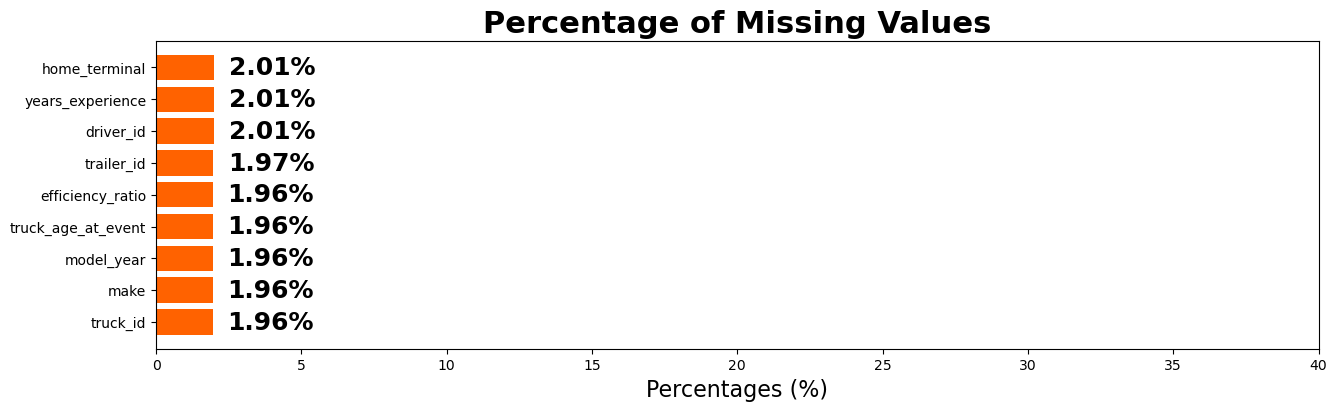

In [6]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [7]:
# Extracting rows with missing values in 'CustomerID' or 'Description' columns
df[df['is_home_terminal'].isnull() | df['years_experience'].isnull()| df['efficiency_ratio'].isnull()| df['truck_age_at_event'].isnull()]

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,...,typical_transit_days,customer_type,month,truck_age_at_event,distance_deviation,is_home_terminal,detention_risk_index,efficiency_ratio,revenue_density,is_winter
132,EVT00000133,LOAD00000067,TRIP00000067,Pickup,FAC00009,2022-01-01 11:00:00.000000,2022-01-01 14:10:03.426897,96,False,Columbus,...,3,Dedicated,1,6.0,164,0,4062.0,0.812857,0.155007,1
133,EVT00000134,LOAD00000067,TRIP00000067,Delivery,FAC00030,2022-01-03 06:10:03.426897,2022-01-03 05:15:42.502952,158,True,Los Angeles,...,3,Dedicated,1,6.0,164,0,2050.0,0.812857,0.155007,1
138,EVT00000139,LOAD00000070,TRIP00000070,Pickup,FAC00028,2022-01-01 08:00:00.000000,2022-01-01 10:14:01.149459,52,False,Phoenix,...,1,Contract,1,NaN,38,0,2488.0,NaN,0.032773,1
139,EVT00000140,LOAD00000070,TRIP00000070,Delivery,FAC00003,2022-01-02 00:26:01.149459,2022-01-02 03:32:28.357242,211,False,Denver,...,1,Contract,1,NaN,38,0,1287.0,NaN,0.032773,1
146,EVT00000147,LOAD00000074,TRIP00000074,Pickup,FAC00005,2022-01-02 07:00:00.000000,2022-01-02 08:49:00.625747,0,True,Philadelphia,...,4,Dedicated,1,NaN,208,0,2616.0,NaN,0.246600,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170479,EVT00170480,LOAD00085240,TRIP00085240,Delivery,FAC00003,2024-12-30 08:12:11.270442,2024-12-30 12:24:14.755622,67,False,Charlotte,...,1,Spot,12,9.0,38,0,4098.0,0.728000,0.188906,1
170496,EVT00170497,LOAD00085249,TRIP00085249,Pickup,FAC00045,2024-12-30 11:00:00.000000,2024-12-30 14:47:45.266716,57,False,Minneapolis,...,3,Contract,12,9.0,0,0,2541.0,0.663000,0.138465,1
170497,EVT00170498,LOAD00085249,TRIP00085249,Delivery,FAC00027,2024-12-31 19:11:45.266716,2024-12-31 17:20:31.512351,51,True,Los Angeles,...,3,Contract,12,9.0,0,0,3238.0,0.663000,0.138465,1
170730,EVT00170731,LOAD00085366,TRIP00085366,Pickup,FAC00021,2024-12-31 08:00:00.000000,2024-12-31 10:07:47.158529,128,False,Philadelphia,...,1,Contract,12,9.0,1,0,2288.0,0.594000,0.006914,1


In [8]:
# Removing rows with missing values in 'CustomerID' and 'Description' columns
df = df.dropna(subset=['is_home_terminal', 'years_experience','efficiency_ratio','truck_age_at_event'])
df.head()

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,...,typical_transit_days,customer_type,month,truck_age_at_event,distance_deviation,is_home_terminal,detention_risk_index,efficiency_ratio,revenue_density,is_winter
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,...,2,Spot,1,7.0,43,0,1051.0,0.89375,0.158779,1
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,...,2,Spot,1,7.0,43,0,1897.0,0.89375,0.158779,1
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,...,1,Spot,1,7.0,-4,0,1457.0,0.68750,0.044106,1
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,...,1,Spot,1,7.0,-4,0,2246.0,0.68750,0.044106,1
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,...,4,Spot,1,4.0,177,0,2166.0,1.48000,0.201464,1


In [9]:
# 1. Count UNIQUE trip_ids for each facility_id
# This ensures we are counting the actual 'Trips' handled by that location
facility_trip_data = df.groupby('facility_id')['trip_id'].nunique().reset_index(name='trips_per_facility')

# 2. Merge this back into your main training dataframe
df = df.merge(facility_trip_data, on='facility_id', how='left')


In [10]:
# 1. Get the unique list of facilities and their trip counts
# 2. Sort by 'trips_per_facility' from highest to lowest
# 3. Take the top 10
top_10_facilities = (
    df[['facility_id', 'trips_per_facility']]
    .drop_duplicates()
    .sort_values(by='trips_per_facility', ascending=False)
    .head(10)
)

print("Top 10 Busiest Facilities (By Trip Volume):")
print(top_10_facilities)

Top 10 Busiest Facilities (By Trip Volume):
   facility_id  trips_per_facility
17    FAC00028                3401
33    FAC00010                3354
10    FAC00043                3353
49    FAC00044                3352
79    FAC00031                3340
25    FAC00003                3332
23    FAC00025                3316
3     FAC00050                3301
82    FAC00039                3292
18    FAC00020                3291


### Top 5 lowest on-time-delivery rate across the states

In [11]:
from IPython.display import display, HTML

# Group by state to see On-Time Percentage vs Trip Count
state_analysis = df.groupby('location_state').agg(
    total_trips=('trip_id', 'nunique'),
    on_time_rate=('on_time_flag', 'mean')
).reset_index()

top_5=state_analysis.sort_values('on_time_rate', ascending=True).head(5)
# Sort by total_trips to see if the top states have the lowest on_time_rate
display(HTML(f"""
<div style="display:flex; justify-content:center;">
    {top_5.to_html(index=False)}
</div>
"""))

location_state,total_trips,on_time_rate
IN,5578,0.442094
CA,8617,0.448416
CO,7078,0.498305
MI,4237,0.521359
WA,11295,0.525365


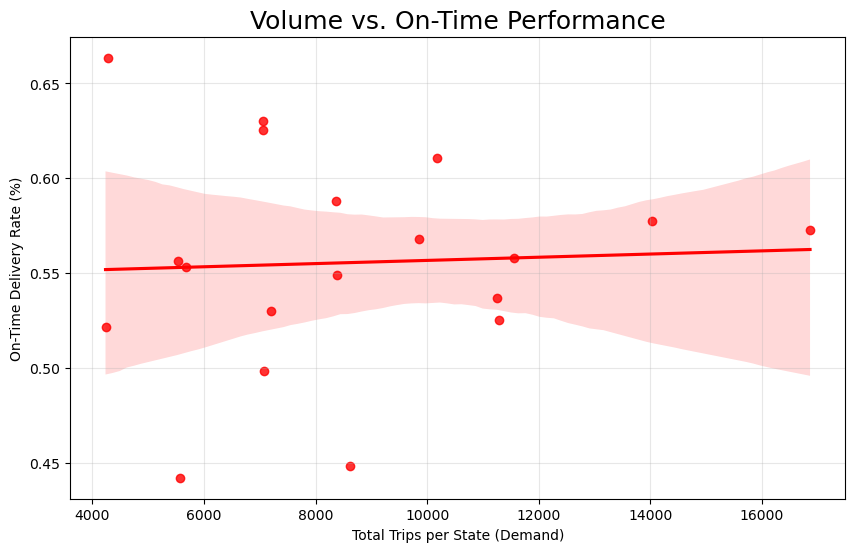

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, HTML
display(HTML("<div style='height:70px;'></div>"))
HTML("<br><br><br><br><br>")

plt.figure(figsize=(10, 6))
sns.regplot(data=state_analysis, x='total_trips', y='on_time_rate', color='red')

plt.title('Volume vs. On-Time Performance',fontsize=18)
plt.xlabel('Total Trips per State (Demand)')
plt.ylabel('On-Time Delivery Rate (%)')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
df['on_time_flag'].value_counts()

on_time_flag
True     91343
False    72779
Name: count, dtype: int64

In [14]:
stats = df[['facility_id', 'trips_per_facility']].drop_duplicates()['trips_per_facility'].describe()
print(stats)

count      50.000000
mean     3249.560000
std        61.393066
min      3113.000000
25%      3223.250000
50%      3245.000000
75%      3287.500000
max      3401.000000
Name: trips_per_facility, dtype: float64


Indiana is showing the lowest on-time rate. If we look at our Trip Density Map, we see that Indiana is a major transit hub.

High Throughput: Because so many national routes pass through Indiana, its facilities often face higher "congestion stress" than coastal states.

Feature Engineering: This validates why location_state is a critical feature. The model will learn that a trip entering Indiana has a statistically higher "Risk Profile" than a trip in a state with a higher on-time rate.

Indiana (IN) as having the lowest on-time delivery rate across the network. Given Indiana's role as a central logistics hub, this suggests that regional congestion—rather than just individual facility issues—is a primary driver of delays. We used this insight to ensure our model weights geographic location heavily when calculating risk scores."

In [15]:
import time
import folium
from geopy.geocoders import Nominatim

# 1. Aggregate Trip Counts by State
# Using size() to count occurrences of each trip per state
state_traffic = (
    df.groupby("location_state")
    .size()
    .reset_index(name="trip_count")
)

# 2. Map State Abbreviations to Full Names
state_map = {
    "AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California",
    "CO":"Colorado","CT":"Connecticut","DE":"Delaware","FL":"Florida","GA":"Georgia",
    "HI":"Hawaii","ID":"Idaho","IL":"Illinois","IN":"Indiana","IA":"Iowa",
    "KS":"Kansas","KY":"Kentucky","LA":"Louisiana","ME":"Maine","MD":"Maryland",
    "MA":"Massachusetts","MI":"Michigan","MN":"Minnesota","MS":"Mississippi",
    "MO":"Missouri","MT":"Montana","NE":"Nebraska","NV":"Nevada","NH":"New Hampshire",
    "NJ":"New Jersey","NM":"New Mexico","NY":"New York","NC":"North Carolina",
    "ND":"North Dakota","OH":"Ohio","OK":"Oklahoma","OR":"Oregon","PA":"Pennsylvania",
    "RI":"Rhode Island","SC":"South Carolina","SD":"South Dakota","TN":"Tennessee",
    "TX":"Texas","UT":"Utah","VT":"Vermont","VA":"Virginia","WA":"Washington",
    "WV":"West Virginia","WI":"Wisconsin","WY":"Wyoming"
}

state_traffic["state_name"] = state_traffic["location_state"].map(state_map)
state_traffic["location"] = state_traffic["state_name"] + ", USA"

# 3. Geocoding with a Timer (Safe for Nominatim)
geolocator = Nominatim(user_agent="trip_density_map", timeout=10)
coords = {}

for loc in state_traffic["location"]:
    if pd.isna(loc): continue 
    try:
        geo = geolocator.geocode(loc)
        if geo:
            coords[loc] = (geo.latitude, geo.longitude)
        else:
            coords[loc] = (None, None)
        time.sleep(1) # Respect Rate Limiting
    except Exception as e:
        coords[loc] = (None, None)

# 4. Map Coordinates back to the Dataframe
state_traffic["lat"] = state_traffic["location"].map(lambda x: coords.get(x, (None, None))[0])
state_traffic["lon"] = state_traffic["location"].map(lambda x: coords.get(x, (None, None))[1])
state_traffic = state_traffic.dropna(subset=["lat", "lon"])

# 5. Create the Folium Map
m = folium.Map(location=[39, -98], zoom_start=4, width=800, height=500)

for _, row in state_traffic.iterrows():
    # Scale radius: Using log or a smaller multiplier since trip counts are high
    # We don't want a circle covering the whole map!
    dynamic_radius = max(5, (row["trip_count"] / df.shape[0]) * 500) 
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=dynamic_radius,
        color="blue", # Using blue to differentiate from the red "Safety" map
        fill=True,
        fill_opacity=0.6,
        popup=f"State: {row['location_state']}<br>Total Trips: {row['trip_count']:,}"
    ).add_to(m)
m